In [ ]:
"""
DiffDock-L analysis
"""
import os
import re
import glob
import numpy as np
import pandas as pd
import mdtraj as md
import matplotlib.pyplot as plt
from pathlib import Path
from rdkit import Chem
from rdkit.Chem import AllChem

try:
    from docking_tools import trajectory_analysis, plotting
    HAS_DOCKING_TOOLS = True
except ImportError:
    print("WARNING: docking_tools not found - interaction fingerprints disabled")
    HAS_DOCKING_TOOLS = False

In [ ]:
# ================================================================
# Parameters and indices (IDENTICAL to Vina script)
# ================================================================
CONTACT_ANG = 6.0
CONTACT_NM  = CONTACT_ANG / 10.0
N_CLUS      = 20

LIGAND_RESID_PAPER = 21
LIG_HEAVY_PAPER = [294, 295, 296, 297, 298, 299, 300, 301, 302, 303,
                   304, 305, 306, 307, 308, 309, 310, 311, 312, 313,
                   316, 317]
LIG_H_PAPER = [314, 315, 318, 319, 320, 321, 322, 323, 324, 325,
               326, 327, 328, 329, 330, 331, 332, 333, 334, 335,
               336, 337]
assert len(LIG_HEAVY_PAPER) == 22
assert len(LIG_H_PAPER) == 22

LIG_HBOND_DONORS_PAPER = [[312, 314], [312, 315]]
LIG_POS_CHARGES_PAPER  = [312]
RING_BENZENE_PAPER     = [300, 301, 302, 303, 304, 305]
RING_5N1_PAPER         = [297, 298, 299, 300, 301]

NH2_H_PAPER       = [314, 315]
NONPOLAR_H_PAPER  = [i for i in LIG_H_PAPER if i not in NH2_H_PAPER]


# ================================================================
# ATOM REMAPPING — derived from find_mapping.py (22/22 element match)
# ================================================================
# SDF_TO_PAPER_HEAVY[sdf_atom_idx] = paper_pdb_global_idx
SDF_TO_PAPER_HEAVY = [306, 307, 308, 309, 310, 311, 312, 313, 316, 317,
                     304, 305, 300, 301, 297, 295, 296, 294, 298, 299,
                     302, 303]
NH2_N_SDF_IDX = 6   # SDF[6] = N+ (NH2 nitrogen), maps to paper[312]
assert SDF_TO_PAPER_HEAVY[NH2_N_SDF_IDX] == 312
assert len(SDF_TO_PAPER_HEAVY) == 22

# Coordinate sanity bounds (reject corrupt poses)
COORD_BOUND_ANG = 500.0

In [ ]:
# ================================================================
# Paths (absolute)
# ================================================================
PAPER_PDB = '/home/zhihanz/data/DiffDock_copy/data/anjali/ligand47/AutoDock_apo.pdb'
DD_RESULTS_DIR = '/home/zhihanz/data/DiffDock_copy/hpc_results/05292026/lig47_ensemble'
PROT_FRAMES_DIR = '/home/zhihanz/data/autodock_vina/protein_frames/protein_frames_apo'
INPUT_SDF = '/home/zhihanz/data/DiffDock_copy/data/asyn_ligands/47_charged.sdf'
OUT_DIR = Path('/home/zhihanz/data/DiffDock_copy/analysis_paper_compatible_lig47_v2')
OUT_DIR.mkdir(exist_ok=True, parents=True)

# Anchored regex for REAL rank1 only — must start with 'rank1_confidence-'
# and end immediately at the numeric value. Excludes rank10..rank19.
RANK1_RE = re.compile(r'^rank1_confidence(-?\d+\.\d+)\.sdf$')
FRAME_ID_RE = re.compile(r'frame_(\d+)')

In [ ]:
# ================================================================
# Helpers
# ================================================================
def compute_bound_fraction_uniform(traj, lig_atom_idx, n_res, cutoff_nm=0.6):
    """IDENTICAL to Vina script."""
    bound = np.zeros((traj.n_frames, n_res), dtype=float)
    lig_xyz = traj.xyz[:, np.asarray(lig_atom_idx, dtype=int), :]
    for ri, res in enumerate(traj.top.residues):
        if not res.is_protein:
            continue
        if ri >= n_res:
            break
        prot_idx = [a.index for a in res.atoms]
        prot_xyz = traj.xyz[:, prot_idx, :]
        diff = prot_xyz[:, :, np.newaxis, :] - lig_xyz[:, np.newaxis, :, :]
        dists = np.sqrt((diff ** 2).sum(axis=-1))
        min_d = dists.reshape(traj.n_frames, -1).min(axis=1)
        bound[:, ri] = (min_d < cutoff_nm).astype(float)
    return bound.mean(axis=0)


def find_rank1_sdf(frame_dir):
    """
    Find THE rank1 pose for this frame.

    Returns (path, confidence) or (None, None) if not found.
    Uses anchored regex that matches ONLY 'rank1_confidence-X.XX.sdf' —
    NOT rank10_*, not the duplicate rank1.sdf.
    """
    for fname in os.listdir(frame_dir):
        m = RANK1_RE.match(fname)
        if m:
            return os.path.join(frame_dir, fname), float(m.group(1))
    return None, None


def parse_diffdock_pose(sdf_path, sdf_to_paper, n_heavy_expected=22):
    """
    Load a DiffDock rank1 SDF and return:
      - heavy_xyz_paper_order:  (n_heavy_expected, 3) in paper PDB ordering (Å)
      - nh2_h_xyz:              (2, 3) coords of the two NH2 hydrogens (Å) or None

    Returns (None, None, reason_string) on failure.
    """
    mol = Chem.MolFromMolFile(sdf_path, sanitize=False, removeHs=False)
    if mol is None:
        return None, None, "RDKit could not load"

    # Drop any existing H — we add them fresh for reproducibility
    if any(a.GetSymbol() == 'H' for a in mol.GetAtoms()):
        ed = Chem.EditableMol(mol)
        for idx in sorted([a.GetIdx() for a in mol.GetAtoms() if a.GetSymbol() == 'H'],
                          reverse=True):
            ed.RemoveAtom(idx)
        mol = ed.GetMol()

    if mol.GetNumAtoms() != n_heavy_expected:
        return None, None, f"expected {n_heavy_expected} heavy, got {mol.GetNumAtoms()}"

    # Extract heavy coords in SDF order
    conf = mol.GetConformer()
    heavy_xyz_sdf = np.array([[conf.GetAtomPosition(i).x,
                               conf.GetAtomPosition(i).y,
                               conf.GetAtomPosition(i).z]
                              for i in range(mol.GetNumAtoms())])

    # Coordinate sanity
    if np.abs(heavy_xyz_sdf).max() > COORD_BOUND_ANG:
        return None, None, f"corrupt coords, max abs = {np.abs(heavy_xyz_sdf).max():.1e}"

    # Reorder SDF -> paper order: heavy_xyz_paper[i] should be the coord of
    # the atom whose paper_idx is LIG_HEAVY_PAPER[i].
    # SDF_TO_PAPER_HEAVY[sdf_i] = paper_global_idx.
    # We need: paper_global_idx -> sdf_i, then heavy_xyz_paper[k] =
    # heavy_xyz_sdf[ sdf_i_for_paper_idx_LIG_HEAVY_PAPER[k] ].
    paper_to_sdf = {p: s for s, p in enumerate(sdf_to_paper)}
    heavy_xyz_paper = np.zeros((n_heavy_expected, 3))
    for k, paper_idx in enumerate(LIG_HEAVY_PAPER):
        heavy_xyz_paper[k] = heavy_xyz_sdf[paper_to_sdf[paper_idx]]

    # Add Hs with 3D coords, then pull out NH2 hydrogens
    mol_h = Chem.AddHs(mol, addCoords=True)
    nh2_n_sdf = NH2_N_SDF_IDX
    nh2_n_atom = mol_h.GetAtomWithIdx(nh2_n_sdf)
    h_neighbors = [n for n in nh2_n_atom.GetNeighbors() if n.GetSymbol() == 'H']
    if len(h_neighbors) < 2:
        # NH2 should have 2 Hs; if AddHs didn't add them, fall back to None
        nh2_h_xyz = None
    else:
        conf_h = mol_h.GetConformer()
        nh2_h_xyz = np.array([[conf_h.GetAtomPosition(h.GetIdx()).x,
                               conf_h.GetAtomPosition(h.GetIdx()).y,
                               conf_h.GetAtomPosition(h.GetIdx()).z]
                              for h in h_neighbors[:2]])

    return heavy_xyz_paper, nh2_h_xyz, "OK"

In [ ]:
# ================================================================
# 1. Topology
# ================================================================
print("=" * 70)
print("STEP 1 - Load paper PDB and verify topology")
print("=" * 70)
ref_paper = md.load(PAPER_PDB)
n_atoms_paper = ref_paper.n_atoms
print(f"Paper PDB: {n_atoms_paper} atoms")

prot_paper_idx = ref_paper.top.select(f"resid 0 to {LIGAND_RESID_PAPER - 1}")
lig_paper_idx_all = ref_paper.top.select(f"resid {LIGAND_RESID_PAPER}")
print(f"Protein atoms: {len(prot_paper_idx)}")
print(f"Ligand atoms:  {len(lig_paper_idx_all)}")

ref_paper_xyz_ang = ref_paper.xyz[0] * 10.0
heavy_centroid_paper = ref_paper_xyz_ang[LIG_HEAVY_PAPER].mean(axis=0)
nonpolar_h_offset = ref_paper_xyz_ang[NONPOLAR_H_PAPER] - heavy_centroid_paper

In [ ]:
# ================================================================
# 2. Walk DiffDock results
# ================================================================
print("\n" + "=" * 70)
print("STEP 2 - Parse DiffDock rank1 SDFs")
print("=" * 70)

frame_dirs = sorted(glob.glob(os.path.join(DD_RESULTS_DIR, "*")))
print(f"Found {len(frame_dirs)} frame directories")

records, failed = [], []
for fd in frame_dirs:
    cname = os.path.basename(fd)
    m = FRAME_ID_RE.search(cname)
    if not m:
        failed.append((cname, "no frame id in name"))
        continue
    fid = int(m.group(1))

    sdf_path, conf = find_rank1_sdf(fd)
    if sdf_path is None:
        failed.append((cname, "no rank1 SDF"))
        continue

    heavy_xyz, nh2_h_xyz, reason = parse_diffdock_pose(sdf_path, SDF_TO_PAPER_HEAVY)
    if heavy_xyz is None:
        failed.append((cname, reason))
        continue

    records.append((fid, conf, heavy_xyz, nh2_h_xyz, sdf_path))

records.sort(key=lambda x: x[0])
print(f"Parsed: {len(records)}, Failed: {len(failed)}")
if failed:
    # Summarize failure reasons
    from collections import Counter
    reason_counts = Counter(r for _, r in failed)
    print("Failure reasons:")
    for reason, count in reason_counts.most_common(10):
        print(f"  {count:5d}  {reason}")

dd_frame_ids = np.array([r[0] for r in records])
dd_scores    = np.array([r[1] for r in records])
print(f"\nConfidence range: {dd_scores.min():.3f} to {dd_scores.max():.3f}")
print(f"  (DiffDock: higher = better; opposite of Vina kcal/mol)")


# ================================================================
# 3. CSV: frame, rank1_confidence, pose_path
# ================================================================
print("\n" + "=" * 70)
print("STEP 3 - Write rank1 scores CSV")
print("=" * 70)
scores_df = pd.DataFrame({
    'frame_id':         dd_frame_ids,
    'rank1_confidence': dd_scores,
    'pose_path':        [r[4] for r in records],
})
scores_csv = OUT_DIR / 'lig47_diffdockL_rank1_scores.csv'
scores_df.to_csv(scores_csv, index=False)
print(f"Wrote {len(scores_df)} rows -> {scores_csv}")

In [ ]:
# ================================================================
# 4. Build trajectory in paper topology
# ================================================================
print("\n" + "=" * 70)
print("STEP 4 - Build DiffDock trajectory with paper PDB topology")
print("=" * 70)

n_frames_dd = len(records)
xyz_dd = np.zeros((n_frames_dd, n_atoms_paper, 3), dtype=np.float32)

n_nh2_ok, missing_prot, n_nh2_fallback = 0, 0, 0
for i, (fid, _, heavy_xyz_paper, nh2_h_xyz, _) in enumerate(records):
    # Protein
    prot_pdb = os.path.join(PROT_FRAMES_DIR,
                            f"protein_only_frame_{fid:05d}_fasudil_apo.pdb")
    if os.path.exists(prot_pdb):
        prot_t = md.load(prot_pdb)
        n_copy = min(prot_t.n_atoms, len(prot_paper_idx))
        xyz_dd[i, prot_paper_idx[:n_copy], :] = prot_t.xyz[0, :n_copy, :]
    else:
        xyz_dd[i, prot_paper_idx, :] = ref_paper.xyz[0, prot_paper_idx, :]
        missing_prot += 1

    # Heavy atoms — already in paper order from parse_diffdock_pose
    xyz_dd[i, LIG_HEAVY_PAPER, :] = heavy_xyz_paper / 10.0   # Å -> nm

    # NH2 hydrogens
    if nh2_h_xyz is not None and len(nh2_h_xyz) == 2:
        xyz_dd[i, NH2_H_PAPER, :] = nh2_h_xyz / 10.0
        n_nh2_ok += 1
    else:
        # Fallback: place H atoms 1.0 Å from N along the NH2 N's natural direction
        # We don't know the direction, so just nudge ±1Å in arbitrary directions.
        # This frame will have noisy h-bond geometry; counted separately.
        n_atom_paper_idx = 312  # NH2 nitrogen in paper coords
        n_pos = xyz_dd[i, n_atom_paper_idx, :]
        xyz_dd[i, 314, :] = n_pos + np.array([0.1, 0.0, 0.0])  # nm
        xyz_dd[i, 315, :] = n_pos + np.array([-0.05, 0.087, 0.0])
        n_nh2_fallback += 1

    # Non-polar H — at heavy centroid + paper offset (same trick as Vina script)
    heavy_centroid = (heavy_xyz_paper / 10.0).mean(axis=0)
    xyz_dd[i, NONPOLAR_H_PAPER, :] = heavy_centroid + nonpolar_h_offset / 10.0

print(f"Frames with proper NH2 Hs:    {n_nh2_ok}")
print(f"Frames with NH2 fallback:     {n_nh2_fallback}")
print(f"Missing per-frame PDBs:       {missing_prot}")

dd_traj = md.Trajectory(xyz_dd, ref_paper.topology)
print(f"\nDiffDock trajectory built: {dd_traj.n_frames} frames, {dd_traj.n_atoms} atoms")

# Sanity check: N-H distances on first frame
sample_n  = dd_traj.xyz[0, 312, :] * 10.0
sample_h1 = dd_traj.xyz[0, 314, :] * 10.0
sample_h2 = dd_traj.xyz[0, 315, :] * 10.0
print(f"Frame 0 N-H1 distance: {np.linalg.norm(sample_n - sample_h1):.3f} Å (expect ~1.0)")
print(f"Frame 0 N-H2 distance: {np.linalg.norm(sample_n - sample_h2):.3f} Å (expect ~1.0)")

# Sanity check: heavy atom centroid should be in protein neighborhood, not at origin
heavy_centroid_frame0 = dd_traj.xyz[0, LIG_HEAVY_PAPER, :].mean(axis=0) * 10.0
print(f"Frame 0 heavy centroid (Å): {heavy_centroid_frame0}")

In [ ]:
# ================================================================
# 5. Bound fraction
# ================================================================
print("\n" + "=" * 70)
print("STEP 5 - Compute bound fraction (uniform)")
print("=" * 70)
n_res_dd = LIGAND_RESID_PAPER
bf_dd_ensemble = compute_bound_fraction_uniform(
    dd_traj, np.array(LIG_HEAVY_PAPER), n_res_dd, CONTACT_NM)
total_bf_dd = bf_dd_ensemble[:20].mean()
print(f"DiffDock-L total bound fraction: {total_bf_dd:.3f}")

In [ ]:
# ================================================================
# 6. Interaction fingerprints (IDENTICAL pipeline to Vina script)
# ================================================================
if HAS_DOCKING_TOOLS:
    print("\n" + "=" * 70)
    print("STEP 6 - Interaction fingerprints (paper-style)")
    print("=" * 70)

    N_BINS = 20
    bin_size = dd_traj.n_frames // N_BINS
    bin_trajs = [dd_traj[i*bin_size:(i+1)*bin_size] for i in range(N_BINS)]
    bin_pop = np.ones(N_BINS) / N_BINS

    contacts = {'hphob': [], 'aro': [], 'hbond': [], 'charge': [], 'dual': []}

    for i, traj in enumerate(bin_trajs):
        print(f"Bin {i+1:>2}: {traj.n_frames} frames", end=" | ")

        try:
            hp = trajectory_analysis.hphob_contacts(traj, LIGAND_RESID_PAPER)
            contacts['hphob'].append(hp)
            print(f"hphob={hp.mean(axis=0).sum():.3f}", end=" | ")
        except Exception as e:
            print(f"hphob ERR:{e}", end=" | ")
            contacts['hphob'].append(np.zeros((traj.n_frames, 20)))

        try:
            ar = trajectory_analysis.aro_contacts(
                traj, ligand_rings=[RING_BENZENE_PAPER])
            contacts['aro'].append(ar)
            print(f"aro={ar.mean(axis=0).sum():.3f}", end=" | ")
        except Exception as e:
            print(f"aro ERR:{e}", end=" | ")
            contacts['aro'].append(np.zeros((traj.n_frames, 20)))

        try:
            hb = trajectory_analysis.hbond(
                traj, LIGAND_RESID_PAPER, lig_hbond_donors=LIG_HBOND_DONORS_PAPER)
            contacts['hbond'].append(hb)
            print(f"hbond={hb.mean(axis=0).sum():.3f}", end=" | ")
        except Exception as e:
            print(f"hbond ERR:{e}", end=" | ")
            contacts['hbond'].append(np.zeros((traj.n_frames, 20)))

        try:
            ch = trajectory_analysis.charge_contacts(
                traj, Ligand_Pos_Charges=LIG_POS_CHARGES_PAPER)
            contacts['charge'].append(ch)
            print(f"charge={ch.mean(axis=0).sum():.3f}", end=" | ")
        except Exception as e:
            print(f"charge ERR:{e}", end=" | ")
            contacts['charge'].append(np.zeros((traj.n_frames, 20)))

        try:
            du = trajectory_analysis.dual_contact(traj, residue_idx=LIGAND_RESID_PAPER)
            contacts['dual'].append(du)
        except Exception as e:
            contacts['dual'].append(None)
        print()

In [ ]:
    contacts_plot = {}
    for key in ['hphob', 'aro', 'hbond', 'charge']:
        per_bin_means = [arr[:, :20].mean(axis=0) if arr is not None
                         else np.zeros(20) for arr in contacts[key]]
        contacts_plot[key] = np.array(per_bin_means)[:, np.newaxis, :]

    dual_v = [d for d in contacts['dual'] if d is not None]
    if dual_v:
        ds = dual_v[0].shape
        contacts_plot['dual'] = np.stack([
            d if d is not None else np.zeros(ds) for d in contacts['dual']])

    plotting.plot_ensemble_ii(contacts_plot, bin_pop[:, np.newaxis])
    plt.suptitle('DiffDock-L (paper-compatible) - Ensemble II', y=1.02)
    plt.savefig(OUT_DIR / 'ensemble_ii_diffdockL.png', dpi=150, bbox_inches='tight')
    plt.show()

    plotting.plot_clus_ii(contacts_plot)
    plt.suptitle('DiffDock-L (paper-compatible) - Per-bin II', y=1.02)
    plt.savefig(OUT_DIR / 'clus_ii_diffdockL.png', dpi=150, bbox_inches='tight')
    plt.show()

    if 'dual' in contacts_plot:
        plotting.plot_ensemble_dual(contacts_plot['dual'], bin_pop)
        plt.suptitle('DiffDock-L (paper-compatible) - Ensemble Dual', y=1.02)
        plt.savefig(OUT_DIR / 'ensemble_dual_diffdockL.png', dpi=150, bbox_inches='tight')
        plt.show()

        plotting.plot_clus_dual(contacts_plot['dual'])
        plt.suptitle('DiffDock-L (paper-compatible) - Per-bin Dual', y=1.02)
        plt.savefig(OUT_DIR / 'clus_dual_diffdockL.png', dpi=150, bbox_inches='tight')
        plt.show()

In [ ]:
# ================================================================
# 7. Save results
# ================================================================
np.savez(OUT_DIR / 'diffdockL_results.npz',
         frame_ids=dd_frame_ids,
         scores=dd_scores,
         bound_fraction=bf_dd_ensemble[:20])

print(f"\nAll outputs in: {OUT_DIR}")
print(f"  - lig47_diffdockL_rank1_scores.csv")
print(f"  - diffdockL_results.npz")
print(f"  - ensemble_ii_diffdockL.png, clus_ii_diffdockL.png")
print(f"  - ensemble_dual_diffdockL.png, clus_dual_diffdockL.png")

STEP 1 - Load paper PDB and verify topology
Paper PDB: 338 atoms
Protein atoms: 294
Ligand atoms:  44

STEP 2 - Parse DiffDock rank1 SDFs
Found 20020 frame directories
Parsed: 19719, Failed: 301
Failure reasons:
    301  no rank1 SDF

Confidence range: -4.760 to 0.300
  (DiffDock: higher = better; opposite of Vina kcal/mol)

STEP 3 - Write rank1 scores CSV
Wrote 19719 rows -> /home/zhihanz/data/DiffDock_copy/analysis_paper_compatible_lig47_v2/lig47_diffdockL_rank1_scores.csv

STEP 4 - Build DiffDock trajectory with paper PDB topology
Frames with proper NH2 Hs:    19719
Frames with NH2 fallback:     0
Missing per-frame PDBs:       0

DiffDock trajectory built: 19719 frames, 338 atoms
Frame 0 N-H1 distance: 1.030 Å (expect ~1.0)
Frame 0 N-H2 distance: 1.030 Å (expect ~1.0)
Frame 0 heavy centroid (Å): [-6.425349 16.221043 12.500354]

STEP 5 - Compute bound fraction (uniform)
DiffDock-L total bound fraction: 0.488

STEP 6 - Interaction fingerprints (paper-style)
Bin  1: 985 frames | hphob=

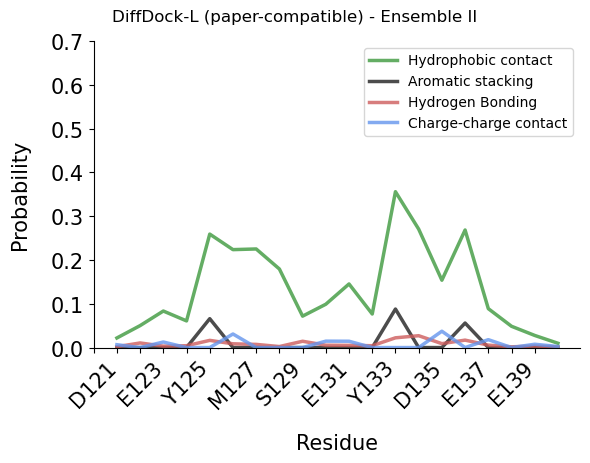

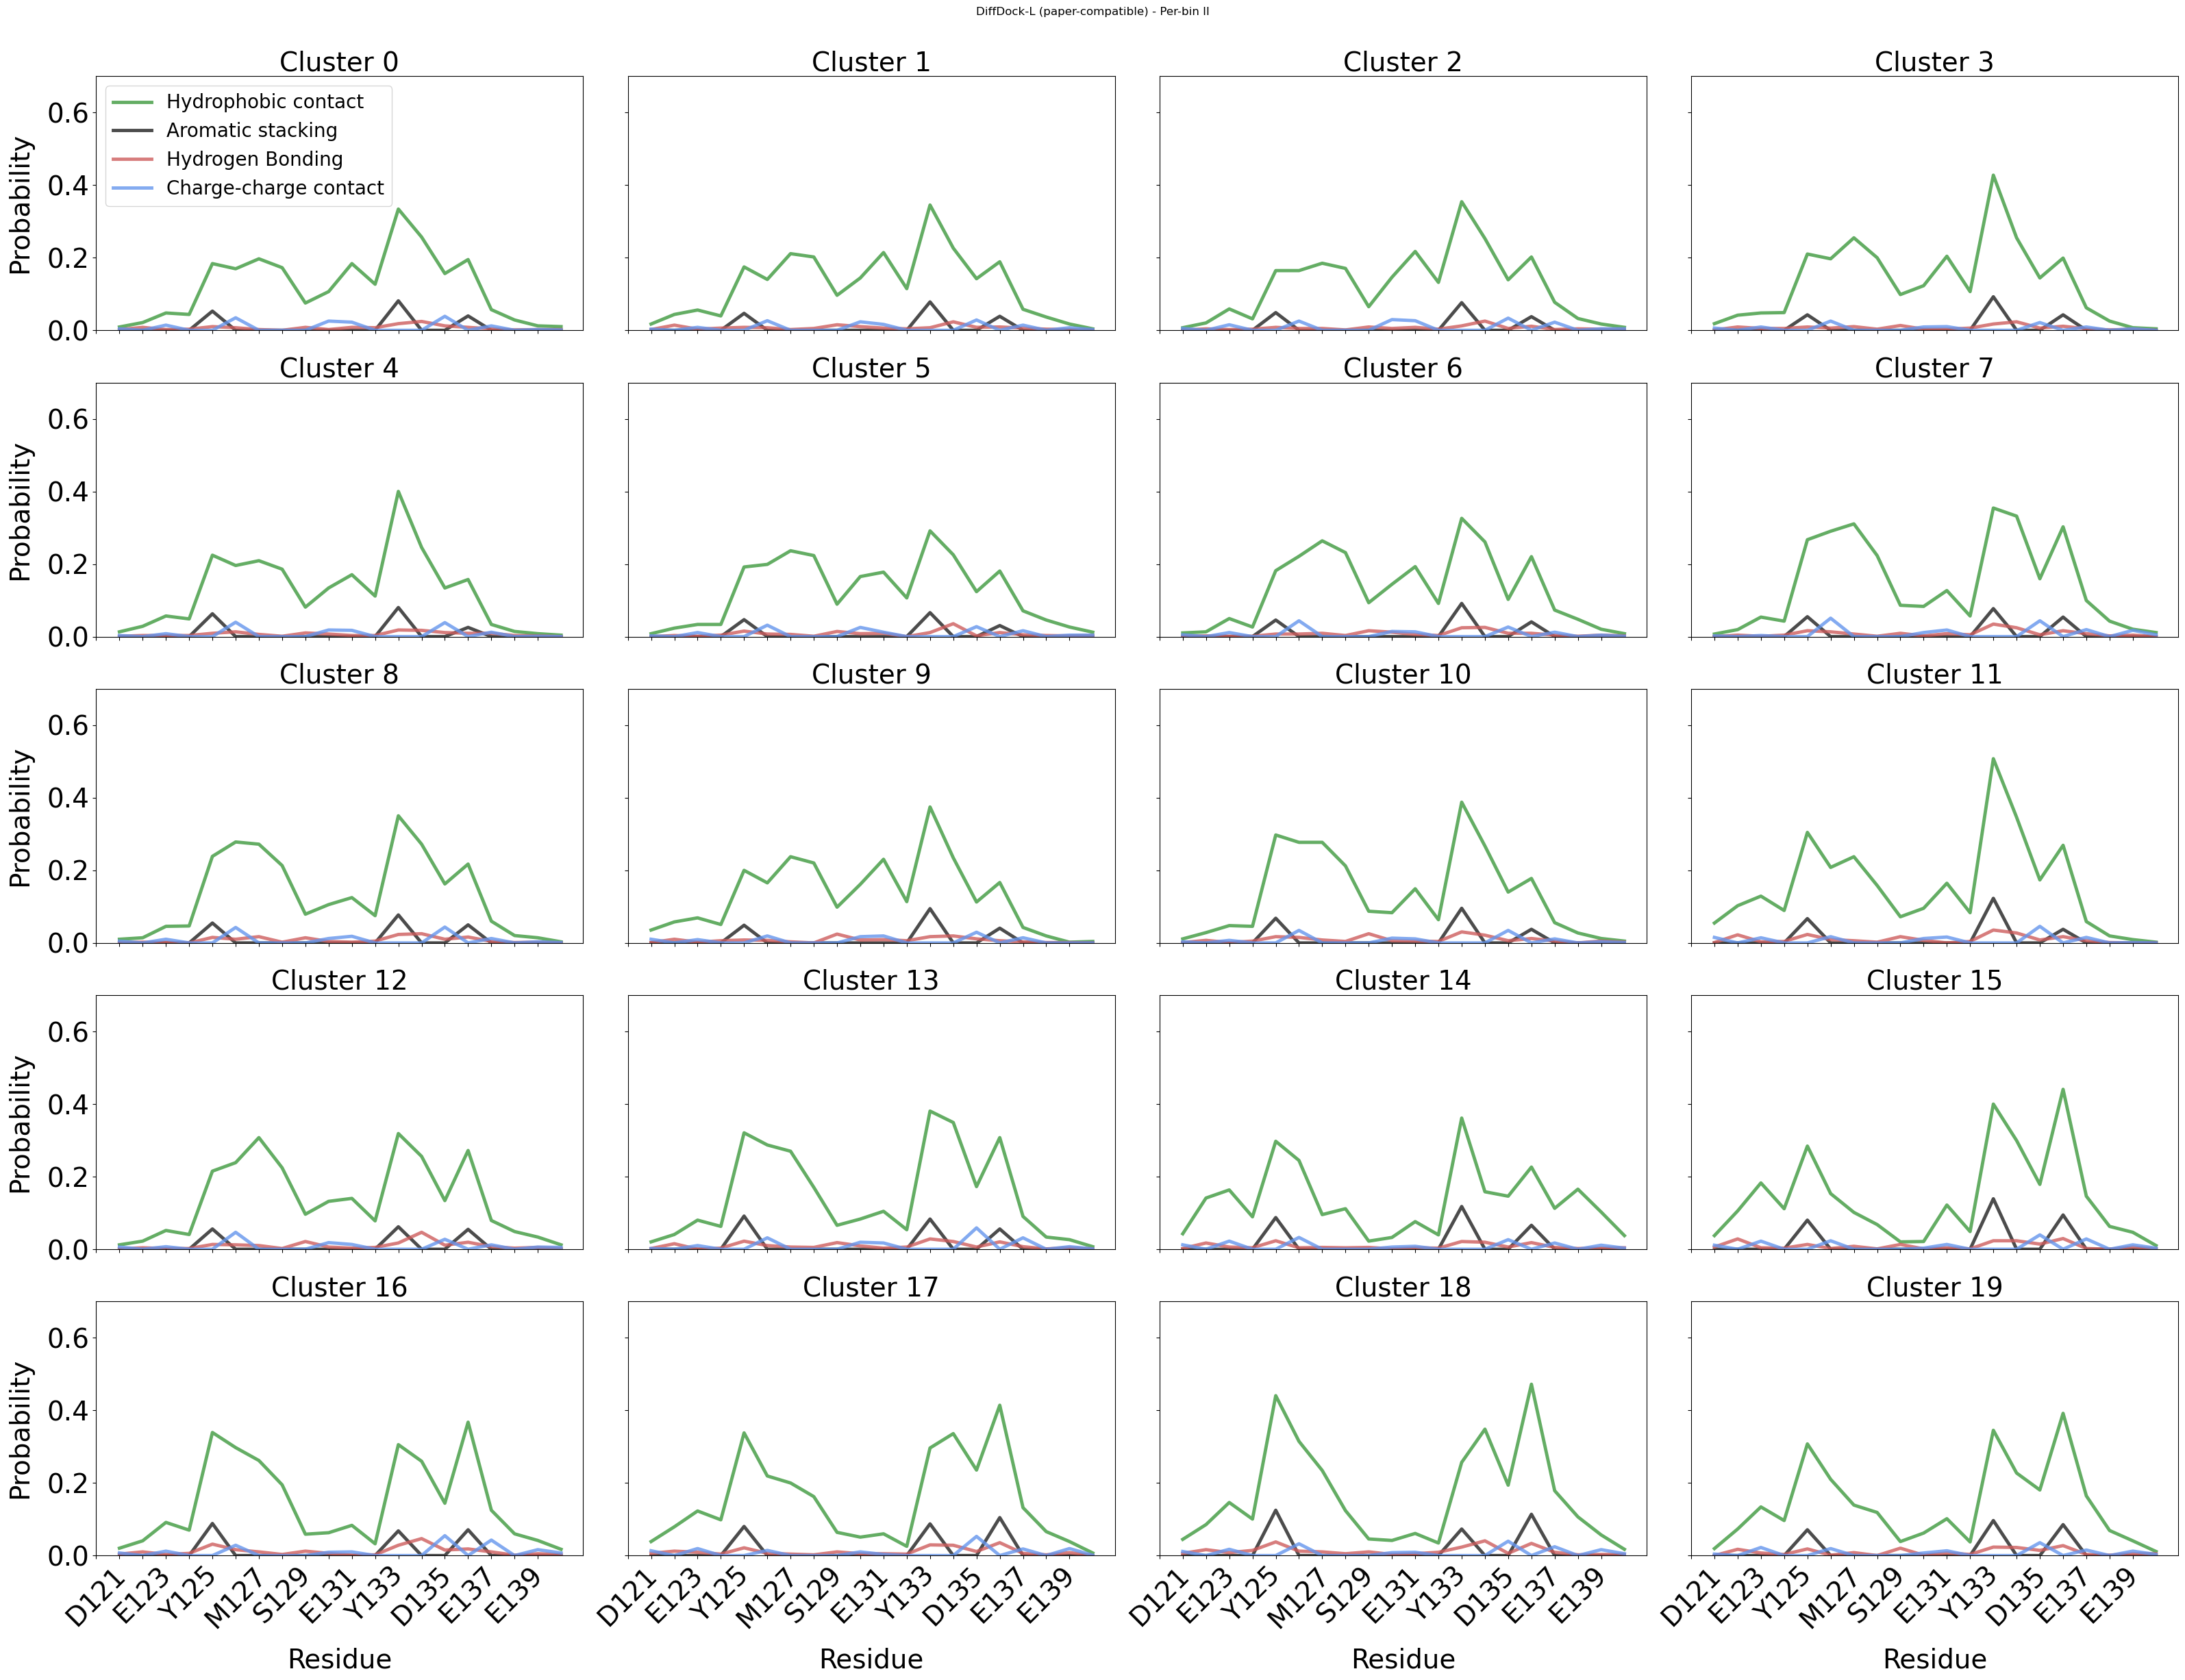

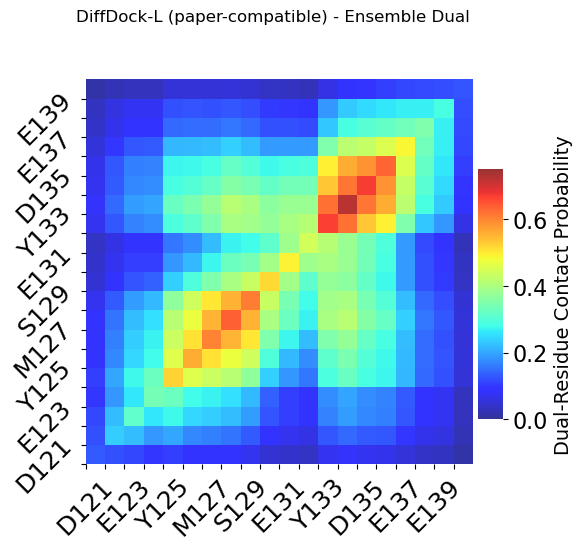

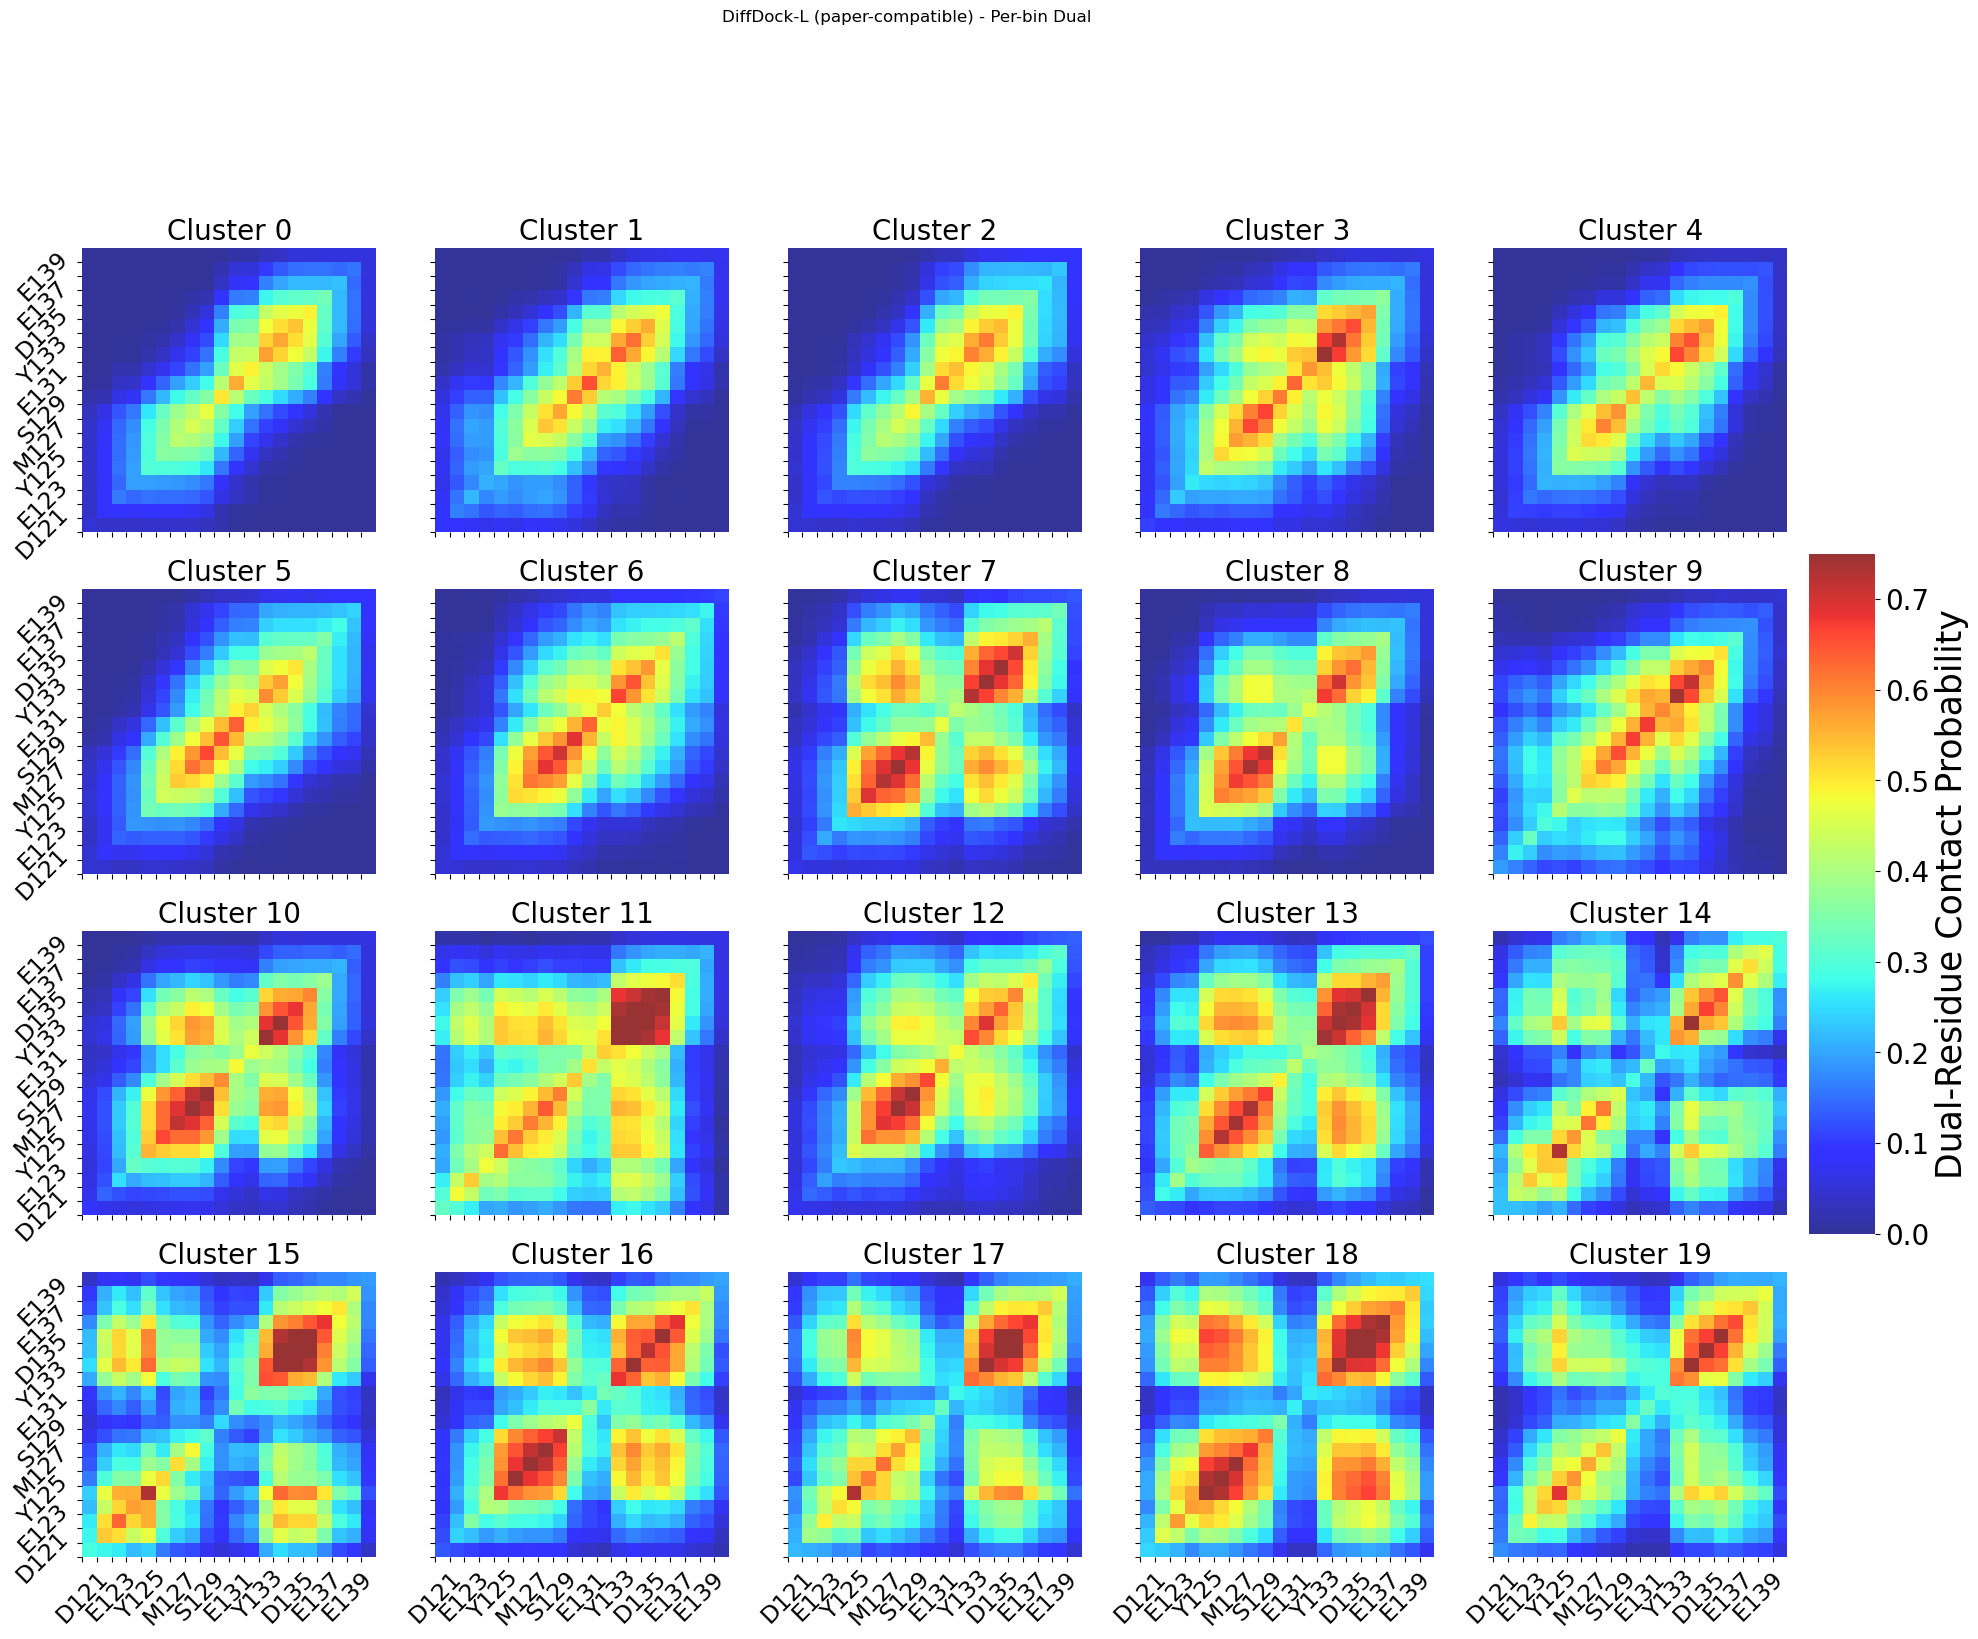


All outputs in: /home/zhihanz/data/DiffDock_copy/analysis_paper_compatible_lig47_v2
  - lig47_diffdockL_rank1_scores.csv
  - diffdockL_results.npz
  - ensemble_ii_diffdockL.png, clus_ii_diffdockL.png
  - ensemble_dual_diffdockL.png, clus_dual_diffdockL.png
